# Data Import

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"/Users/dhananjayjape/Desktop/Windows 11/Full Projects/Pricing Strategy Analysis/Online_Retail.csv",encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


# Data Preprocessing

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [3]:
df = df.drop(columns='CustomerID')
df.isnull().sum()

InvoiceNo         0
StockCode         0
Description    1454
Quantity          0
InvoiceDate       0
UnitPrice         0
Country           0
dtype: int64

In [4]:
df = df.dropna(subset=['Description'])
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
Country        0
dtype: int64

In [5]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [6]:
df = df[(df['Quantity']>0)]
df = df[(df['UnitPrice']>0)]

In [7]:
#Convert Date
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    format='mixed'
)

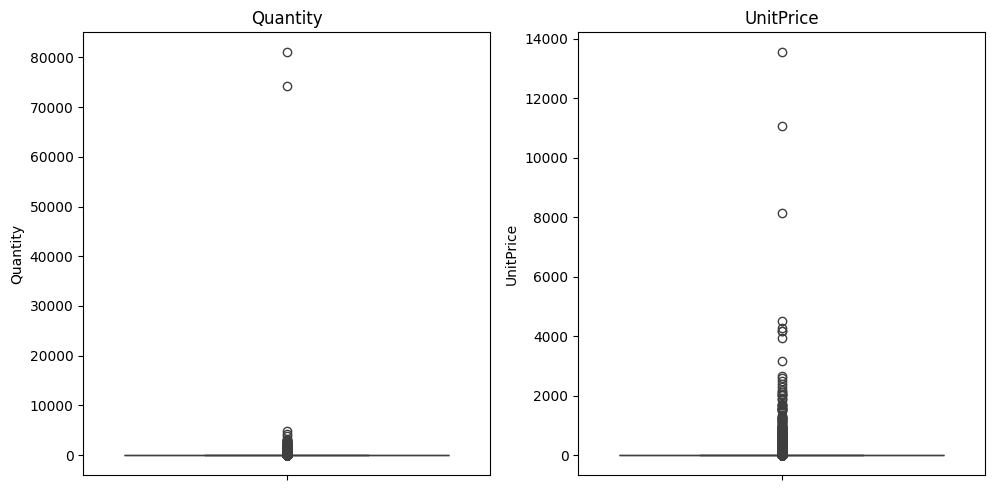

In [8]:
# Checking Outliers
num_cols = df.select_dtypes(include=['number']).columns

import matplotlib.pyplot as plt
import seaborn as sns
import math

# Select numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Calculate number of rows needed
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [9]:
# Handle Quantity outliers
Q1_q = df['Quantity'].quantile(0.25)
Q3_q = df['Quantity'].quantile(0.75)

IQR_q = Q3_q - Q1_q

lower_q = Q1_q - 1.5 * IQR_q
upper_q = Q3_q + 1.5 * IQR_q

df['Quantity'] = df['Quantity'].clip(lower_q, upper_q)


# Handle UnitPrice outliers
Q1_p = df['UnitPrice'].quantile(0.25)
Q3_p = df['UnitPrice'].quantile(0.75)

IQR_p = Q3_p - Q1_p

lower_p = Q1_p - 1.5 * IQR_p
upper_p = Q3_p + 1.5 * IQR_p

df['UnitPrice'] = df['UnitPrice'].clip(lower_p, upper_p)


# Recalculate Revenue AFTER handling outliers
df['Revenue'] = df['Quantity'] * df['UnitPrice']

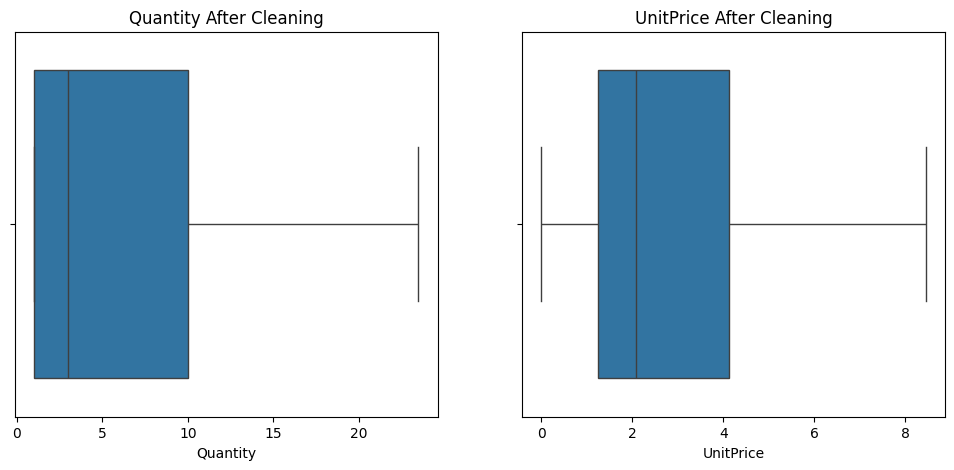

In [10]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['Quantity'])
plt.title("Quantity After Cleaning")

plt.subplot(1,2,2)
sns.boxplot(x=df['UnitPrice'])
plt.title("UnitPrice After Cleaning")

plt.show()

# Exlporatory Data Analysis

In [11]:
product_summary = df.groupby('StockCode').agg({
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'Revenue': 'sum'
}).reset_index()

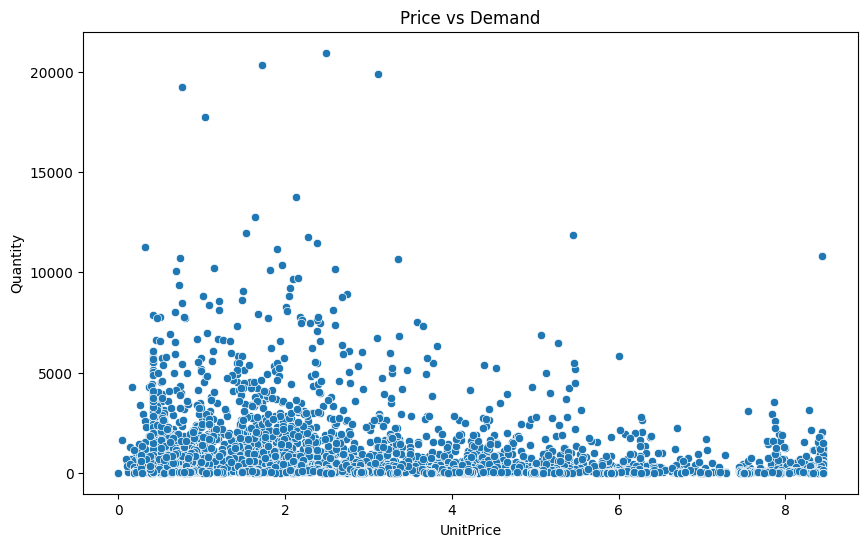

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=product_summary,
    x='UnitPrice',
    y='Quantity'
)

plt.title("Price vs Demand")
plt.show()

# Calculate Product-Level Elasticity

In [13]:
product_summary = df.groupby(
    ['StockCode','Description']
).agg({
    'Quantity': 'sum',
    'UnitPrice': 'mean',
    'Revenue': 'sum'
}).reset_index()

In [14]:
import numpy as np

product_summary['LogPrice'] = np.log1p(product_summary['UnitPrice'])
product_summary['LogQuantity'] = np.log1p(product_summary['Quantity'])

# Create Elasticity Regression

In [15]:
import numpy as np
import statsmodels.api as sm

elasticity_list = []

for product in df['StockCode'].unique():

    product_df = df[df['StockCode'] == product]

    # Need enough data points
    if len(product_df) > 10:

        product_df = product_df.sort_values('InvoiceDate')

        product_df['LogPrice'] = np.log1p(product_df['UnitPrice'])
        product_df['LogQuantity'] = np.log1p(product_df['Quantity'])

        X = sm.add_constant(product_df['LogPrice'])
        y = product_df['LogQuantity']

        try:
            model = sm.OLS(y, X).fit()

            elasticity = model.params['LogPrice']

            elasticity_list.append({
                'StockCode': product,
                'Elasticity': elasticity
            })

        except:
            continue

elasticity_df = pd.DataFrame(elasticity_list)

elasticity_df.head()

,StockCode,Elasticity
0,85123A,-2.300685
1,71053,-0.792184
2,84406B,-1.513643
3,84029G,-0.685525
4,84029E,-0.804011


In [16]:
elasticity_df['DemandType'] = elasticity_df[
    'Elasticity'
].apply(
    lambda x: 'Elastic' if abs(x) > 1 else 'Inelastic'
)

elasticity_df['DemandType'].value_counts()

DemandType
Elastic      2376
Inelastic     765
Name: count, dtype: int64

In [17]:
product_summary = product_summary.merge(
    elasticity_df,
    on='StockCode',
    how='left'
)

In [18]:
demand_revenue = product_summary.groupby(
    'DemandType'
)['Revenue'].sum().reset_index()

demand_revenue

,DemandType,Revenue
0,Elastic,5806577.420
1,Inelastic,1247459.281


# Multi-Discount Simulation

In [19]:
discount_rates = [0.05, 0.10, 0.15]

results = []

base_revenue = product_summary['Revenue'].sum()

for d in discount_rates:

    elastic_products = product_summary[
        product_summary['DemandType'] == 'Elastic'
    ].copy()

    inelastic_products = product_summary[
        product_summary['DemandType'] == 'Inelastic'
    ]

    # New price
    elastic_products['NewPrice'] = (
        elastic_products['UnitPrice'] * (1 - d)
    )

    # Demand increase
    elastic_products['NewQuantity'] = (
        elastic_products['Quantity'] *
        (1 + abs(elastic_products['Elasticity']) * d)
    )

    # New revenue
    elastic_products['NewRevenue'] = (
        elastic_products['NewPrice'] *
        elastic_products['NewQuantity']
    )

    total_new_revenue = (
        elastic_products['NewRevenue'].sum() +
        inelastic_products['Revenue'].sum()
    )

    results.append(total_new_revenue)


discount_df = pd.DataFrame({
    'Scenario': ['5% Discount','10% Discount','15% Discount'],
    'Revenue': results
})

discount_df

,Scenario,Revenue
0,5% Discount,8.571724e+06
1,10% Discount,9.188063e+06
2,15% Discount,9.693089e+06


In [20]:
discount_df['Revenue_Millions'] = (
    discount_df['Revenue'] / 1_000_000
)

discount_df

,Scenario,Revenue,Revenue_Millions
0,5% Discount,8.571724e+06,8.571724
1,10% Discount,9.188063e+06,9.188063
2,15% Discount,9.693089e+06,9.693089


# Revenue Comparison Across Pricing Strategies

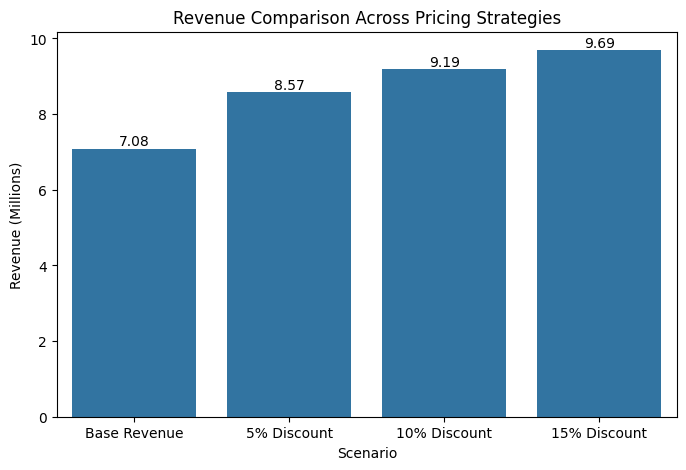

In [21]:
# Create comparison dataframe
comparison_df = pd.concat([
    pd.DataFrame({
        'Scenario': ['Base Revenue'],
        'Revenue': [product_summary['Revenue'].sum()]
    }),
    discount_df
])

# Convert Revenue to Millions
comparison_df['Revenue_Millions'] = (
    comparison_df['Revenue'] / 1_000_000
)

# Plot
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=comparison_df,
    x='Scenario',
    y='Revenue_Millions'
)

# Add value labels
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')

plt.title("Revenue Comparison Across Pricing Strategies")
plt.ylabel("Revenue (Millions)")
plt.xlabel("Scenario")

plt.show()

# Top Elastic Products

In [22]:
top_elastic_products = elasticity_df.sort_values(
    by='Elasticity'
).head(10)

top_elastic_products

,StockCode,Elasticity,DemandType
2502,84905,-657.490425,Elastic
2605,79063C,-158.656564,Elastic
2738,23079,-70.681878,Elastic
130,22424,-70.525903,Elastic
2756,23085,-66.055322,Elastic
3033,23471,-58.766287,Elastic
595,84968C,-58.246817,Elastic
1505,85066,-57.850070,Elastic
3072,23487,-51.345341,Elastic
2716,23173,-49.988293,Elastic


In [23]:
elastic_unique = elasticity_df.merge(
    product_summary[['StockCode','Description']],
    on='StockCode',
    how='left'
)

# Clean Description text
elastic_unique['Description'] = (
    elastic_unique['Description']
    .str.strip()      # Remove extra spaces
    .str.upper()      # Make uppercase
)

In [24]:
# Sort by elasticity (most negative first)
elastic_unique = elastic_unique.sort_values(
    by='Elasticity'
)

# Remove duplicate product names
elastic_unique = elastic_unique.drop_duplicates(
    subset='Description',
    keep='first'
)

# Select top 10
top_elastic_products = elastic_unique.head(10)

top_elastic_products

,StockCode,Elasticity,DemandType,Description
2598,84905,-657.490425,Elastic,PINK BUTTERFLY CUSHION COVER
2709,79063C,-158.656564,Elastic,"RETRO PILL BOX KEY CHAIN,THE KING"
2880,23079,-70.681878,Elastic,TOADSTOOL BEDSIDE LIGHT
140,22424,-70.525903,Elastic,ENAMEL BREAD BIN CREAM
2904,23085,-66.055322,Elastic,ANTIQUE SILVER BAUBLE LAMP
3240,23471,-58.766287,Elastic,SIX DRAWER OFFICE TIDY
628,84968C,-58.246817,Elastic,SET OF 16 VINTAGE PISTACHIO CUTLERY
1571,85066,-57.850070,Elastic,CREAM SWEETHEART MINI CHEST
3300,23487,-51.345341,Elastic,SWEET HEART CAKE CARRIER
2853,23173,-49.988293,Elastic,REGENCY TEAPOT ROSES


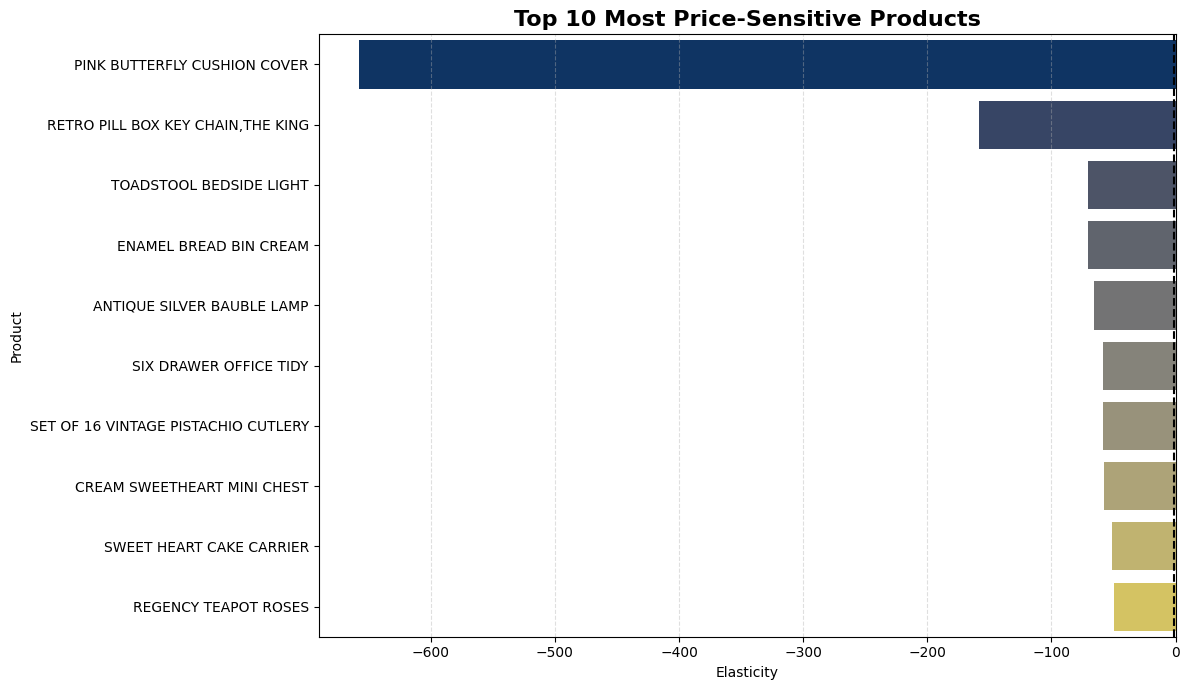

In [25]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_elastic_products,
    y='Description',
    x='Elasticity',
    palette='cividis'
)

plt.axvline(
    x=-1,
    color='black',
    linestyle='--'
)

plt.title(
    "Top 10 Most Price-Sensitive Products",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Elasticity")
plt.ylabel("Product")

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

# Recommended Products To Discount 

### Products with High Elasticity and High Revenue

In [26]:
discount_candidates = product_summary.copy()

discount_candidates = discount_candidates[
    discount_candidates['DemandType'] == 'Elastic'
]

discount_candidates['DiscountScore'] = (
    abs(discount_candidates['Elasticity']) *
    discount_candidates['Revenue']
)

top_discount_products = discount_candidates.sort_values(
    by='DiscountScore',
    ascending=False
).head(10)

top_discount_products[
    ['StockCode','Description','Elasticity','Revenue']
]

,StockCode,Description,Elasticity,Revenue
2132,23173,REGENCY TEAPOT ROSES,-49.988293,14683.250
3602,85066,CREAM SWEETHEART MINI CHEST,-57.850070,12341.920
1341,22424,ENAMEL BREAD BIN CREAM,-70.525903,7175.450
1536,22624,IVORY KITCHEN SCALES,-18.354892,14851.450
2269,23284,DOORMAT KEEP CALM AND COME IN,-7.979195,26004.450
1340,22423,REGENCY CAKESTAND 3 TIER,-2.257800,91125.100
2030,23085,ANTIQUE SILVER BAUBLE LAMP,-66.055322,2976.000
696,21621,VINTAGE UNION JACK BUNTING,-11.468085,17101.020
1125,22193,RED DINER WALL CLOCK,-18.028049,10678.175
2393,23397,FOOT STOOL HOME SWEET HOME,-47.914333,3968.400


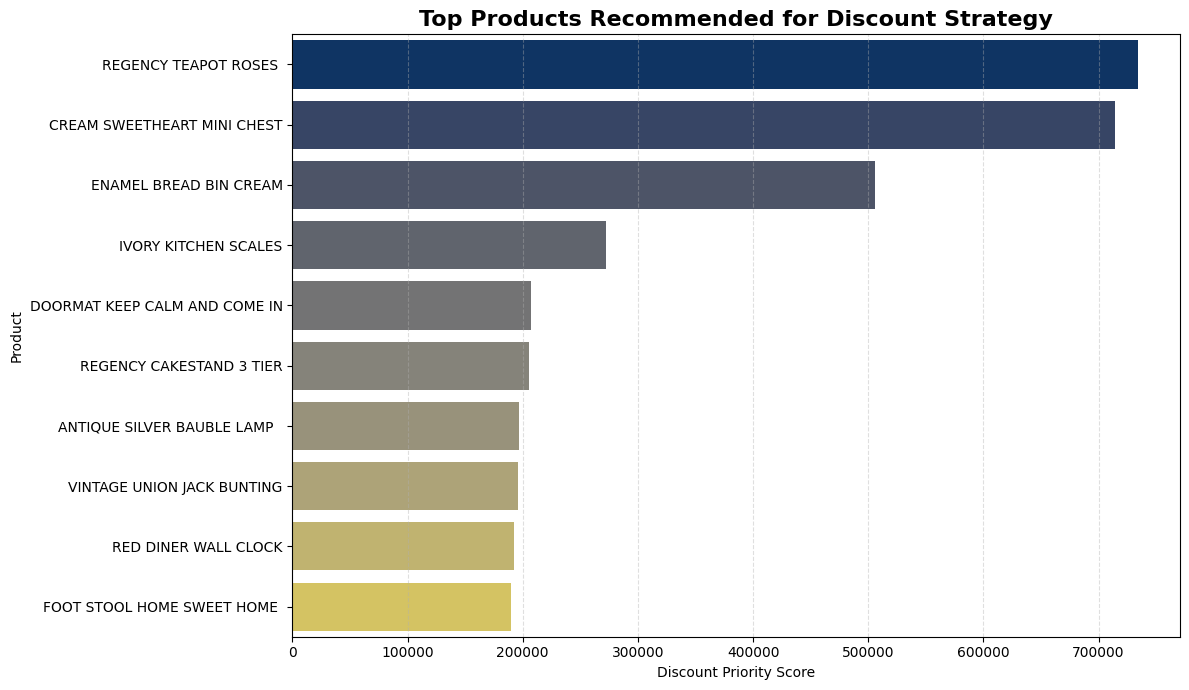

In [27]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_discount_products,
    y='Description',
    x='DiscountScore',
    palette='cividis'
)

plt.title(
    "Top Products Recommended for Discount Strategy",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Discount Priority Score")
plt.ylabel("Product")

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

### Products with Low Elasticity and High Revenue

In [28]:
# Remove non-product items
invalid_products = [
    'POSTAGE',
    'DOTCOM POSTAGE',
    'BANK CHARGES',
    'MANUAL'
]

product_summary = product_summary[
    ~product_summary['Description']
    .str.upper()
    .isin(invalid_products)
]

In [29]:
premium_candidates = product_summary.copy()

premium_candidates = premium_candidates[
    premium_candidates['DemandType'] == 'Inelastic'
]

premium_candidates = premium_candidates[
    abs(premium_candidates['Elasticity']) > 0.1
]

premium_candidates['PremiumScore'] = (
    premium_candidates['Revenue'] /
    abs(premium_candidates['Elasticity'])
)

premium_candidates['PremiumScore_M'] = (
    premium_candidates['PremiumScore'] / 1_000_000
)

top_premium_products = premium_candidates.sort_values(
    by='PremiumScore',
    ascending=False
).head(10)

top_premium_products[
    ['StockCode','Description','Elasticity','Revenue']
]

,StockCode,Description,Elasticity,Revenue
1050,22114,HOT WATER BOTTLE TEA AND SYMPATHY,0.213708,22324.245
177,20723,STRAWBERRY CHARLOTTE BAG,-0.103129,8598.985
1279,22355,CHARLOTTE BAG SUKI DESIGN,-0.134254,11105.805
627,21479,WHITE SKULL HOT WATER BOTTLE,0.189652,14085.360
1022,22086,PAPER CHAIN KIT 50'S CHRISTMAS,-0.572390,34906.985
1414,22501,PICNIC BASKET WICKER LARGE,0.195402,10710.770
1635,22726,ALARM CLOCK BAKELIKE GREEN,-0.525881,22896.995
3416,84879,ASSORTED COLOUR BIRD ORNAMENT,-0.852266,34694.435
1636,22727,ALARM CLOCK BAKELIKE RED,-0.595342,22570.530
2285,23298,SPOTTY BUNTING,-0.900296,32812.850


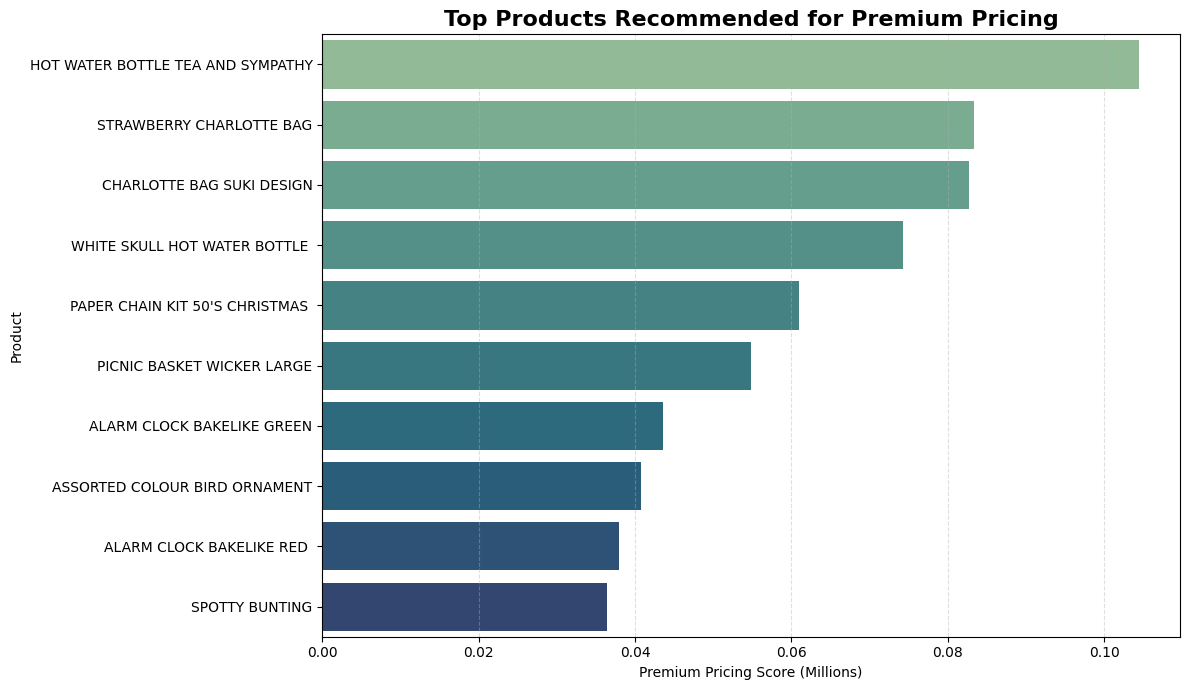

In [30]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_premium_products,
    y='Description',
    x='PremiumScore_M',
    palette='crest'
)

plt.title(
    "Top Products Recommended for Premium Pricing",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Premium Pricing Score (Millions)")
plt.ylabel("Product")

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

# Bundling Strategy [Market Basket Analysis (Apriori)]

In [31]:
from mlxtend.frequent_patterns import apriori, association_rules

top_products = df['Description'].value_counts().head(100).index

df_filtered = df[
    df['Description'].isin(top_products)
]

basket = df_filtered.groupby(
    ['InvoiceNo','Description']
)['Quantity'].sum().unstack().fillna(0)

basket = (basket > 0).astype(int)

basket.head()

Description,6 RIBBONS RUSTIC CHARM,60 TEATIME FAIRY CAKE CASES,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE PINK,ALARM CLOCK BAKELIKE RED,ANTIQUE SILVER T-LIGHT GLASS,ASSORTED COLOUR BIRD ORNAMENT,BAKING SET 9 PIECE RETROSPOT,CHARLOTTE BAG PINK POLKADOT,CHARLOTTE BAG SUKI DESIGN,...,SPACEBOY LUNCH BOX,SPOTTY BUNTING,STRAWBERRY CERAMIC TRINKET BOX,STRAWBERRY CHARLOTTE BAG,VICTORIAN GLASS HANGING T-LIGHT,VINTAGE SNAP CARDS,WHITE HANGING HEART T-LIGHT HOLDER,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,WOODLAND CHARLOTTE BAG
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
536367,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536370,0,0,1,1,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
536371,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_items.head()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/mlxtend/frequent_patterns/fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.059487,frozenset({6 RIBBONS RUSTIC CHARM})
1,0.051576,frozenset({60 TEATIME FAIRY CAKE CASES})
2,0.061044,frozenset({ALARM CLOCK BAKELIKE GREEN})
3,0.048773,frozenset({ALARM CLOCK BAKELIKE PINK})
4,0.065467,frozenset({ALARM CLOCK BAKELIKE RED })


In [33]:
rules = association_rules(
    frequent_items,
    metric="lift",
    min_threshold=1
)

rules = rules.sort_values(
    by='lift',
    ascending=False
)

top_bundles = rules[
    ['antecedents',
     'consequents',
     'support',
     'confidence',
     'lift']
].head(10)

top_bundles

,antecedents,consequents,support,confidence,lift
316,"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",frozenset({PINK REGENCY TEACUP AND SAUCER}),0.033699,0.705346,14.802113
321,frozenset({PINK REGENCY TEACUP AND SAUCER}),"frozenset({GREEN REGENCY TEACUP AND SAUCER, RO...",0.033699,0.707190,14.802113
300,"frozenset({CHARLOTTE BAG SUKI DESIGN, RED RETR...",frozenset({STRAWBERRY CHARLOTTE BAG}),0.020805,0.658777,14.648210
301,frozenset({STRAWBERRY CHARLOTTE BAG}),"frozenset({CHARLOTTE BAG SUKI DESIGN, RED RETR...",0.020805,0.462604,14.648210
287,"frozenset({STRAWBERRY CHARLOTTE BAG, RED RETRO...",frozenset({CHARLOTTE BAG PINK POLKADOT}),0.020306,0.670782,14.513117
290,frozenset({CHARLOTTE BAG PINK POLKADOT}),"frozenset({STRAWBERRY CHARLOTTE BAG, RED RETRO...",0.020306,0.439353,14.513117
395,"frozenset({WOODLAND CHARLOTTE BAG, RED RETROSP...",frozenset({STRAWBERRY CHARLOTTE BAG}),0.020369,0.647525,14.398009
398,frozenset({STRAWBERRY CHARLOTTE BAG}),"frozenset({WOODLAND CHARLOTTE BAG, RED RETROSP...",0.020369,0.452909,14.398009
319,frozenset({GREEN REGENCY TEACUP AND SAUCER}),"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",0.033699,0.534057,14.337383
318,"frozenset({ROSES REGENCY TEACUP AND SAUCER , P...",frozenset({GREEN REGENCY TEACUP AND SAUCER}),0.033699,0.904682,14.337383


In [34]:
top_bundles['Product_A'] = top_bundles[
    'antecedents'
].apply(lambda x: ', '.join(list(x)))

top_bundles['Product_B'] = top_bundles[
    'consequents'
].apply(lambda x: ', '.join(list(x)))

top_bundles = top_bundles[
    ['Product_A','Product_B',
     'support','confidence','lift']
]

top_bundles

,Product_A,Product_B,support,confidence,lift
316,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.033699,0.705346,14.802113
321,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.033699,0.707190,14.802113
300,"CHARLOTTE BAG SUKI DESIGN, RED RETROSPOT CHARL...",STRAWBERRY CHARLOTTE BAG,0.020805,0.658777,14.648210
301,STRAWBERRY CHARLOTTE BAG,"CHARLOTTE BAG SUKI DESIGN, RED RETROSPOT CHARL...",0.020805,0.462604,14.648210
287,"STRAWBERRY CHARLOTTE BAG, RED RETROSPOT CHARLO...",CHARLOTTE BAG PINK POLKADOT,0.020306,0.670782,14.513117
290,CHARLOTTE BAG PINK POLKADOT,"STRAWBERRY CHARLOTTE BAG, RED RETROSPOT CHARLO...",0.020306,0.439353,14.513117
395,"WOODLAND CHARLOTTE BAG, RED RETROSPOT CHARLOTT...",STRAWBERRY CHARLOTTE BAG,0.020369,0.647525,14.398009
398,STRAWBERRY CHARLOTTE BAG,"WOODLAND CHARLOTTE BAG, RED RETROSPOT CHARLOTT...",0.020369,0.452909,14.398009
319,GREEN REGENCY TEACUP AND SAUCER,"ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY...",0.033699,0.534057,14.337383
318,"ROSES REGENCY TEACUP AND SAUCER , PINK REGENCY...",GREEN REGENCY TEACUP AND SAUCER,0.033699,0.904682,14.337383
